### 1. 데이터 불러오기 및 결측치 처리

In [34]:
# - pandas를 이용하여 prj_data.csv 파일을 불러오고, info()와 isnull().sum()을 이용하여 컬럼별 결측치 개수를 확인하시오.
import pandas as pd
df = pd.read_csv('prj_data.csv')

print('데이터 프레임의 컬럼별 정보')
df.info()
print()
print('컬럼별 결측치 개수 확인')
df.isnull().sum()

데이터 프레임의 컬럼별 정보
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       460 non-null    float64
 2   성별       485 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     480 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     475 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  메모       216 non-null    str    
 11  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 47.0 KB

컬럼별 결측치 개수 확인


고객ID         0
나이          40
성별          15
거주지역         0
가입경로        20
멤버십등급        0
월평균구매금액      0
구매횟수         0
리뷰점수        25
쿠폰사용여부       0
메모         284
이탈여부         0
dtype: int64

In [35]:
# - 결측치가 존재하는 컬럼 중 수치형 변수는 평균 또는 중앙값으로, 범주형 변수는 최빈값으로 대체하시오. (단, 결측 비율이 50%를 초과하는 컬럼은 삭제)
# 수치형 변수 처리
df_num_cols = df.select_dtypes(include='number').columns # Index(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부'], dtype='str')
df_num_cols_na = df_num_cols[df[df_num_cols].isnull().any()] # Index(['나이', '리뷰점수'], dtype='str') 결측치가 존재하는 수치형 변수들

print(df_num_cols)
print(df_num_cols_na)


Index(['나이', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부'], dtype='str')
Index(['나이', '리뷰점수'], dtype='str')


In [36]:
# 나이 --> 중앙값
df[df_num_cols_na[0]] = df[df_num_cols_na[0]].fillna(df[df_num_cols_na[0]].median())

# 리뷰점수 --> 평균
df[df_num_cols_na[1]] = df[df_num_cols_na[1]].fillna(df[df_num_cols_na[1]].mean())

In [37]:
# 범주형 변수 처리
df_cat_cols = df.select_dtypes(exclude='number').columns # Index(['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부', '메모'], dtype='str')
df_cat_cols_na = df_cat_cols[df[df_cat_cols].isnull().any()] # Index(['성별', '가입경로', '메모'], dtype='str')

print(df_cat_cols)
print(df_cat_cols_na)

Index(['고객ID', '성별', '거주지역', '가입경로', '멤버십등급', '쿠폰사용여부', '메모'], dtype='str')
Index(['성별', '가입경로', '메모'], dtype='str')


In [38]:
# 범주형 변수 --> 최빈값
for c in df_cat_cols_na:
    df[c] = df[c].fillna(df[c].mode()[0])

In [39]:
# - 처리 후 결측치가 모두 제거되었는지 다시 확인하는 코드를 작성하시오.
df.isnull().sum()

고객ID       0
나이         0
성별         0
거주지역       0
가입경로       0
멤버십등급      0
월평균구매금액    0
구매횟수       0
리뷰점수       0
쿠폰사용여부     0
메모         0
이탈여부       0
dtype: int64

### 2. 이상치 탐지 및 처리

In [40]:
df.describe()

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,97684.003413,7.822000,3.736632,0.380000
std,14.384764,106309.940848,4.481795,0.540323,0.485873
min,18.000000,19127.903927,1.000000,2.500000,0.000000
25%,32.000000,48362.456334,4.000000,3.400000,0.000000
50%,43.000000,74770.324856,7.000000,3.700000,0.000000
75%,56.000000,114551.098353,10.250000,4.100000,1.000000
max,69.000000,945072.807028,21.000000,5.000000,1.000000


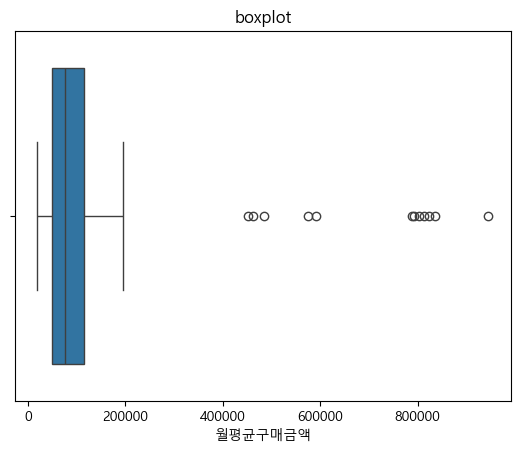

In [41]:
# - 수치형 변수 중 1개 이상을 선택하여 boxplot으로 이상치를 시각화하시오.
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(x=df['월평균구매금액'])
plt.title('boxplot')
plt.show()


In [42]:
# - IQR(사분위수 범위) 기법을 이용하여 이상치의 하한/상한 경계값을 계산하는 코드를 작성하시오.
# Q1 (1사분위수) 25%
q1 = df['월평균구매금액'].quantile(.25)

# Q3 (3사분위수) 75%
q3 = df['월평균구매금액'].quantile(.75)

iqr = q3- q1

# 하한
lower = q1 - 1.5*iqr

# 상한
upper = q3 + 1.5*iqr

print(f'하위 0.25% {q1}')
print(f'하위 0.75% {q3}')
print(f'하한 {lower}')
print(f'상한 {upper}')


하위 0.25% 48362.456334193215
하위 0.75% 114551.09835296536
하한 -50920.50669396499
상한 213834.06138112355


In [43]:
# - 계산된 경계값을 기준으로 이상치를 제거하거나, 경계값으로 대체(capping)하시오. 처리 방식과 그 이유를 주석으로 명시하시오.
# 이상치의 개수
n_outlier = (df['월평균구매금액'] < lower) | (df['월평균구매금액'] > upper)
n_outlier.sum()

np.int64(12)

In [44]:
# 월평균구매금액은 표본 수가 적을수록 뒤쪽 EDA(그룹 비교)에서 신뢰도가 떨어지므로 표본을 유지하면서 극단값만 완화하는 capping이 더 적합하다.
df['월평균구매금액'] = df['월평균구매금액'].clip(lower, upper)

### 3. 범주형 변수 인코딩

In [45]:
# - 범주형 변수 중 순서 의미가 없는 변수는 원-핫 인코딩(pd.get_dummies 또는 OneHotEncoder)을, 순서 의미가 있는 변수는 레이블 인코딩(LabelEncoder)을 적용하시오.
# - 인코딩 전/후의 데이터프레임 형태(shape)와 컬럼 목록을 비교하여 출력하시오.

print(df.shape)
print(df.columns)



(500, 12)
Index(['고객ID', '나이', '성별', '거주지역', '가입경로', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수',
       '쿠폰사용여부', '메모', '이탈여부'],
      dtype='str')


In [49]:
# - 왜 해당 인코딩 방식을 선택했는지 주석 또는 마크다운 셀로 근거를 서술하시오.

# '쿠폰사용여부'는 범주형 변수이며 값이 Y/N 두 가지뿐이다.
# 모델이 범주 간 대소관계를 학습하지 않도록 One-Hot Encoding을 적용하였다.
df[['쿠폰사용 N','쿠폰사용 Y']] = pd.get_dummies(df['쿠폰사용여부'])

# '거주지역'은 서울, 부산, 대구 등 여러 범주를 가지는 문자열 데이터이다.
# 지역 간 순서나 크기의 의미는 없지만 문자열을 그대로 사용할 수 없으므로
# 각 지역을 고유한 정수로 변환하는 Label Encoding을 적용하였다.
# (트리 기반 모델에서는 정수 인코딩을 사용해도 큰 문제가 없으며,
# 차원이 불필요하게 증가하는 것을 방지할 수 있다.)
df['거주지역_label_encoding'] = pd.factorize(df['거주지역'])[0]

print(df.shape)
print(df.columns)

(500, 15)
Index(['고객ID', '나이', '성별', '거주지역', '가입경로', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수',
       '쿠폰사용여부', '메모', '이탈여부', '쿠폰사용 N', '쿠폰사용 Y', '거주지역_label_encoding'],
      dtype='str')


### 4. 파생변수 생성 및 스케일링

In [51]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler # 정규화, 표준화

In [61]:
# - 기존 컬럼 2개 이상을 조합하여 분석에 의미 있는 파생변수를 1개 이상 생성하시오. (예: 비율, 합계, 구간화 등)
df['ratio'] = df['구매횟수'] / df['리뷰점수']


In [62]:
# - StandardScaler 또는 MinMaxScaler 중 하나를 선택하여 수치형 변수를 스케일링하시오.
df_norm = df[df_num_cols]

minmax = MinMaxScaler()

result1 = minmax.fit_transform(df_norm)
# 데이터프레임으로 만들어서 결과확인

df_num_norm_sklearn = pd.DataFrame(
    result1, 
    columns=df_norm.columns
)

df_num_norm_sklearn.head()


,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
0,0.078431,0.223813,0.30,0.32,1.0
1,0.784314,0.830836,0.85,0.88,0.0
2,0.666667,0.058754,0.10,0.32,0.0
3,0.431373,0.269307,0.10,0.52,0.0
4,0.431373,0.456275,0.30,0.96,0.0


In [63]:
# - 스케일링 전/후 기술통계량(describe())을 비교 출력하여 변화가 반영되었음을 확인하시오.

df_norm.describe() # 스케일링 전

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,86092.413399,7.822000,3.736632,0.380000
std,14.384764,47003.366902,4.481795,0.540323,0.485873
min,18.000000,19127.903927,1.000000,2.500000,0.000000
25%,32.000000,48362.456334,4.000000,3.400000,0.000000
50%,43.000000,74770.324856,7.000000,3.700000,0.000000
75%,56.000000,114551.098353,10.250000,4.100000,1.000000
max,69.000000,213834.061381,21.000000,5.000000,1.000000


In [64]:
df_num_norm_sklearn.describe() # 스케일링 후

,나이,월평균구매금액,구매횟수,리뷰점수,이탈여부
count,500.000000,500.000000,500.00000,500.000000,500.000000
mean,0.493725,0.343926,0.34110,0.494653,0.380000
std,0.282054,0.241407,0.22409,0.216129,0.485873
min,0.000000,0.000000,0.00000,0.000000,0.000000
25%,0.274510,0.150147,0.15000,0.360000,0.000000
50%,0.490196,0.285776,0.30000,0.480000,0.000000
75%,0.745098,0.490088,0.46250,0.640000,1.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000


In [65]:
# - 최종 전처리 완료 데이터를 prj_data_cleaned.csv로 저장하는 코드를 작성하시오.

df.to_csv('prj_data_final.csv', index=False)
pd.read_csv('prj_data_final.csv')

,고객ID,나이,성별,거주지역,가입경로,멤버십등급,월평균구매금액,구매횟수,리뷰점수,쿠폰사용여부,메모,이탈여부,쿠폰사용 N,쿠폰사용 Y,거주지역_label_encoding,ratio
0,C0001,22.0,남,대구,앱,실버,62705.653045,7.0,3.3,N,재구매 유도 대상,1,True,False,0,2.121212
1,C0002,58.0,여,부산,웹,VIP,180896.754122,18.0,4.7,Y,재구매 유도 대상,0,False,True,1,3.829787
2,C0003,52.0,여,기타,앱,브론즈,30567.640969,3.0,3.3,Y,재구매 유도 대상,0,False,True,2,0.909091
3,C0004,40.0,여,경기,앱,실버,71563.606370,3.0,3.8,N,재구매 유도 대상,0,True,False,3,0.789474
4,C0005,40.0,남,경기,웹,골드,107967.380320,7.0,4.9,N,재구매 유도 대상,0,True,False,3,1.428571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,C0496,39.0,여,경기,웹,골드,108578.954159,9.0,3.5,N,재구매 유도 대상,0,True,False,3,2.571429
496,C0497,24.0,여,대구,광고,브론즈,40162.047877,6.0,3.6,N,재구매 유도 대상,1,True,False,0,1.666667
497,C0498,37.0,남,서울,웹,브론즈,51493.570059,3.0,4.1,Y,재구매 유도 대상,0,False,True,4,0.731707
498,C0499,66.0,여,기타,앱,골드,105068.989111,6.0,4.4,N,VIP 응대 필요,0,True,False,2,1.363636
